# SIOC 251 – Homework 3 Notebook

## Monte Carlo Model with Isotropic Scattering

**Name:** Amanda Mallinckrodt  
**Date:** 05/14/26

## Problem Statement
Modify the previously made Monte Carlo model for a solely absorbing atmosphere to account for isotropic scattering 

### **Isotropic Scattering Derivation**

To sample a new scattering angle $\theta$ for an isotropic distribution, we use the **Cumulative Distribution Function (CDF)** method.

#### **1. The Probability Density Function (PDF)**
For isotropic scattering, the probability of scattering into a given cosine angle $P(\cos\theta)$ is uniform:
$$P(\cos\theta) = 1$$

#### **2. Integrating the CDF**
The CDF, $C(\cos\theta)$, is the integral of the PDF from the minimum possible value ($-1$) to the current value ($\cos\theta$), normalized by 1/2 to get a total of 1:
$$C(\cos\theta) = \frac{1}{2} \int_{-1}^{\cos\theta} P(x) \, dx$$
$$C(\cos\theta) = \frac{1}{2} \int_{-1}^{\cos\theta} 1 \, dx$$
$$C(\cos\theta) = \frac{1}{2} [x]_{-1}^{\cos\theta}$$
$$C(\cos\theta) = \frac{1}{2} (\cos\theta - (-1))$$
$$C(\cos\theta) = \frac{\cos\theta + 1}{2}$$

#### **3. Solving for $\cos\theta$**
We set the CDF equal to a uniform random variable $\xi$ (where $0 \le \xi < 1$) to sample the angle:
$$\xi = \frac{\cos\theta + 1}{2}$$
$$2\xi = \cos\theta + 1$$
$$\mathbf{\cos\theta = 2\xi - 1}$$

---

* **Uniform Probability:** Isotropic scattering means there is an equal probability of scattering into any direction
* **Backscattering:** Because $\cos\theta$ is allowed to be less than $0$ (ranging from $-1$ to $1$), the photon has the potential to backscatter in the upward direction


### **Azimuthal Angle ($\phi$) Derivation**

#### **1. The Probability Function**
The total range of the circle is $2\pi$ radians. For an isotropic distribution, the probability must be constant:
$$P(\phi) = N$$

so the total probability equals $1$:
$$\int_{0}^{2\pi} N \, d\phi = 1 \implies N [ \phi ]_{0}^{2\pi} = 1 \implies 2\pi N = 1$$
$$\mathbf{P(\phi) = \frac{1}{2\pi}}$$

#### **2. Integrating the CDF**
$$C(\phi) = \int_{0}^{\phi} \frac{1}{2\pi} \, d\phi'$$
$$C(\phi) = \frac{1}{2\pi} [ \phi' ]_{0}^{\phi}$$
$$C(\phi) = \frac{\phi}{2\pi}$$

#### **3. Solving for $\phi$**
a uniform random variable $\xi$ is between $0 \le \xi < 1$:
$$\xi = \frac{\phi}{2\pi}$$
$$\mathbf{\phi = 2\pi\xi}$$



In [96]:
import numpy as np

# --- Updated Parameters ---
N_INCIDENT = 10000 
TAU_STAR = 3
SZA_DEG = 30    
Z_ATM = 8500 
OMEGA_TILDE = 0.9

def run_simulation_with_scattering():
    # Initial setup
    mu_initial = np.cos(np.radians(SZA_DEG))
    
    surf_count = 0
    absorbed_count = 0
    toa_escape_count = 0

    for _ in range(N_INCIDENT):
        # Initial State
        current_tau = 0.0
        current_mu = mu_initial  # Positive is downward
        active = True
        
        while active:
            # 1. Sample optical path length
            zeta1 = np.random.rand()
            delta_tau = -np.log(1 - zeta1)
            new_tau = current_tau + (delta_tau * current_mu)
            
            # Check Boundaries
            if new_tau >= TAU_STAR:
                surf_count += 1
                active = False
            elif new_tau <= 0:
                toa_escape_count += 1
                active = False
            else:
                zeta2 = np.random.rand()
                
                if zeta2 < OMEGA_TILDE:
                    # SCATTERING EVENT
                    current_tau = new_tau
                    # Sample new isotropic direction (cos theta between -1 and 1)
                    zeta3 = np.random.rand()
                    current_mu = 2 * zeta3 - 1 
                    
                 
                    if abs(current_mu) < 0.001: 
                        current_mu = 0.001 if current_mu >= 0 else -0.001
                else:
                    # ABSORPTION EVENT
                    absorbed_count += 1
                    active = False

    # Statistics
    print(f"RESULTS (Albedo={OMEGA_TILDE})")
    print(f"Surface Hits:  {surf_count} ({surf_count/N_INCIDENT*100:.2f}%)")
    print(f"Absorbed:      {absorbed_count} ({absorbed_count/N_INCIDENT*100:.2f}%)")
    print(f"Escaped TOA:   {toa_escape_count} ({toa_escape_count/N_INCIDENT*100:.2f}%)")

run_simulation_with_scattering()

RESULTS (Albedo=0.9)
Surface Hits:  1934 (19.34%)
Absorbed:      3930 (39.30%)
Escaped TOA:   4136 (41.36%)


### **3D Scattering Geometry Derivation**

A local coordinate system was then used to simulate scattering in 3D and trace the photon path, before converting back to the real-world atmospheric coordinate system.

#### **1. Establishing the Local Coordinates $(\hat{x}_p, \hat{y}_p, \hat{z}_p)$**
When a photon scatters, we define a local orthonormal basis where the current direction of travel is the local z-axis:
* **Local Z-axis ($\hat{z}_p$):** The current normalized direction vector $\mathbf{k}_{old}$.
* **Local X-axis ($\hat{x}_p$):** A vector perpendicular to $\hat{z}_p$, found using:
    $$\hat{x}_p = \frac{1}{\sqrt{k_x^2 + k_y^2}} \begin{pmatrix} -k_y \\ k_x \\ 0 \end{pmatrix}$$
* **Local Y-axis ($\hat{y}_p$):** The cross product of the other two to ensure orthonormality:
    $$\hat{y}_p = \hat{z}_p \times \hat{x}_p$$

#### **2. Scattering Direction ($\mathbf{k}_p$)**
Using the scattering angles (Zenith $\theta$ and Azimuth $\phi$), we define the new direction in this local "unit sphere" coordinate system:
$$\mathbf{k}_p = \begin{pmatrix} \sin\theta \cos\phi \\ \sin\theta \sin\phi \\ \cos\theta \end{pmatrix}$$

#### **3. The Rotation Matrix**
To align this local direction with the global atmosphere, we construct a rotation matrix $A$ using our local basis vectors as columns:
$$A = \begin{pmatrix} \vdots & \vdots & \vdots \\ \hat{x}_p & \hat{y}_p & \hat{z}_p \\ \vdots & \vdots & \vdots \end{pmatrix}$$

The new global direction $\mathbf{k}_{new}$ is the linear combination of these basis vectors:
$$\mathbf{k}_{new} = A \cdot \mathbf{k}_p = (k_{p,x})\hat{x}_p + (k_{p,y})\hat{y}_p + (k_{p,z})\hat{z}_p$$

#### **4. Normalization**
To prevent numerical drift and maintain consistent step lengths, the final vector is normalized:
$$\mathbf{k}_{final} = \frac{\mathbf{k}_{new}}{\|\mathbf{k}_{new}\|}$$

NameError: name 'save_fig' is not defined

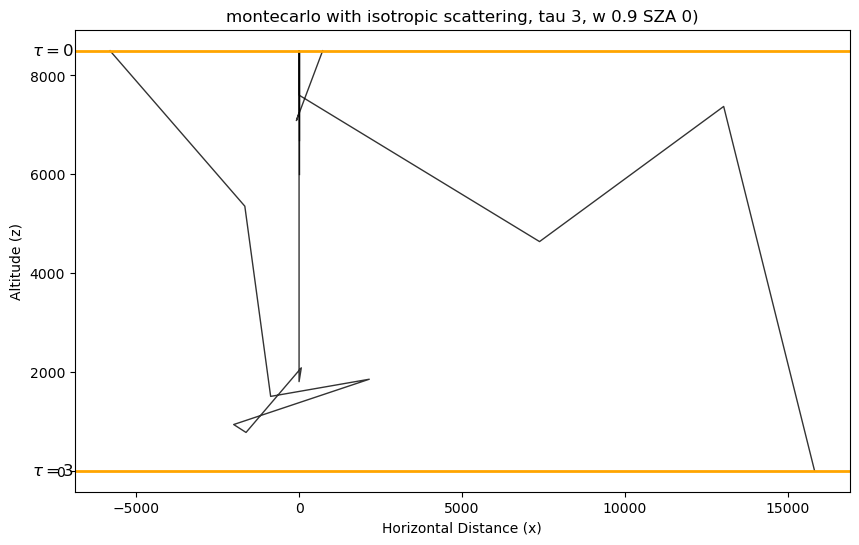

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N_INCIDENT = 10000 
N_PLOT = 5           # Number of paths to display visually
TAU_STAR = 3         # Optical Depth
OMEGA_TILDE = 0.9      # 0 for pure absorption, 1 for pure scattering
SZA_DEG = 0         # Solar Zenith Angle
Z_ATM = 8500         # Physical Height of Atmosphere

def scatter_3d(k_old, cos_theta, phi_scat):
    zp = k_old / np.linalg.norm(k_old)
    kx, ky, kz = zp
    
    if abs(kx) < 1e-9 and abs(ky) < 1e-9:
        xp = np.array([1.0, 0.0, 0.0])
    else:
        norm = 1.0 / np.sqrt(kx**2 + ky**2)
        xp = np.array([-ky * norm, kx * norm, 0.0])
    
    yp = np.cross(zp, xp)
    sin_theta = np.sqrt(max(0, 1 - cos_theta**2))
    kp = np.array([sin_theta * np.cos(phi_scat), 
                   sin_theta * np.sin(phi_scat), 
                   cos_theta])
    
    A = np.stack([xp, yp, zp], axis=1)
    k_new = A @ kp
    return k_new / np.linalg.norm(k_new)

def run_simulation():
    plt.figure(figsize=(10, 6))
    

    dz_dtau = Z_ATM / TAU_STAR 

    # Initial direction vector
    sza_rad = np.radians(SZA_DEG)
    k_init = np.array([np.sin(sza_rad), 0, -np.cos(sza_rad)])

   
    n_scatter_total = 0
    n_absorbed = 0
    n_reflected = 0
    n_transmitted = 0

    for i in range(N_INCIDENT):
        pos = np.array([0.0, 0.0, Z_ATM]) 
        k = k_init.copy()
        path_x, path_z = [pos[0]], [pos[2]]
        active = True
        
        while active:
            # Sample optical path
            delta_tau = -np.log(1 - np.random.rand())
            
            
            step = k * (delta_tau * dz_dtau)
            new_pos = pos + step
            
            # Boundary Checks
            if new_pos[2] <= 0: # Hit Surface
                # Interpolate to find exact exit point at z=0
                fraction = pos[2] / abs(step[2]) if step[2] != 0 else 0
                final_pos = pos + step * fraction
                path_x.append(final_pos[0]); path_z.append(0)
                n_transmitted += 1
                active = False
            elif new_pos[2] >= Z_ATM: # Escaped TOA
                fraction = (Z_ATM - pos[2]) / step[2] if step[2] != 0 else 0
                final_pos = pos + step * fraction
                path_x.append(final_pos[0]); path_z.append(Z_ATM)
                n_reflected += 1
                active = False
            else:
                # Still inside atmosphere
                pos = new_pos
                path_x.append(pos[0]); path_z.append(pos[2])
                
                # Interaction Logic
                if np.random.rand() < OMEGA_TILDE:
                    n_scatter_total += 1
                    cos_theta = 2 * np.random.rand() - 1
                    phi_scat = 2 * np.pi * np.random.rand()
                    k = scatter_3d(k, cos_theta, phi_scat)
                else:
                    n_absorbed += 1
                    active = False

        # Plot first few paths
        if i < N_PLOT:
            plt.plot(path_x, path_z, color='black', linewidth=1, alpha=0.8)

    # --- Formatting Plot ---
    plt.axhline(y=Z_ATM, color='orange', linewidth=2)
    plt.axhline(y=0, color='orange', linewidth=2)
    plt.text(plt.xlim()[0], Z_ATM, r'$\tau = 0$ ', fontsize=12, va='center', ha='right')
    plt.text(plt.xlim()[0], 0, fr'$\tau = {TAU_STAR}$ ', fontsize=12, va='center', ha='right')
    plt.title(fr"Monte Carlo: $\tau={TAU_STAR}, \tilde{{\omega}}={OMEGA_TILDE}$, SZA={SZA_DEG}°")
    plt.ylabel("Altitude (z)")
    plt.xlabel("Horizontal Distance (x)")
    plt.title("montecarlo with isotropic scattering, tau 3, w 0.9 SZA 0)")
    save_fig()


    # --- Print Final Statistics ---
    print("-" * 35)
    print(f"SIMULATION RESULTS (N={N_INCIDENT})")
    print("-" * 35)
    print(f"Transmitted to Surface: {n_transmitted} ({n_transmitted/N_INCIDENT*100:.2f}%)")
    print(f"Reflected to Space:     {n_reflected} ({n_reflected/N_INCIDENT*100:.2f}%)")
    print(f"Absorbed in Atmosphere: {n_absorbed} ({n_absorbed/N_INCIDENT*100:.2f}%)")
    print("-" * 35)
    print(f"Theoretical Transmission: {np.exp(-TAU_STAR/np.cos(sza_rad))*100:.2f}%")
    print(f"Avg Scatters per Photon: {n_scatter_total/N_INCIDENT:.2f}")

# Run it
run_simulation()

### **Model Verification and Extinction Analysis**

To ensure the Monte Carlo simulation is accurate, we compare the numerical outputs against theoretical radiative transfer principles.

#### **1. Single Scattering Albedo ($\tilde{\omega}$) Verification**
* **$\tilde{\omega} = 0$:** Only absorption occurs.
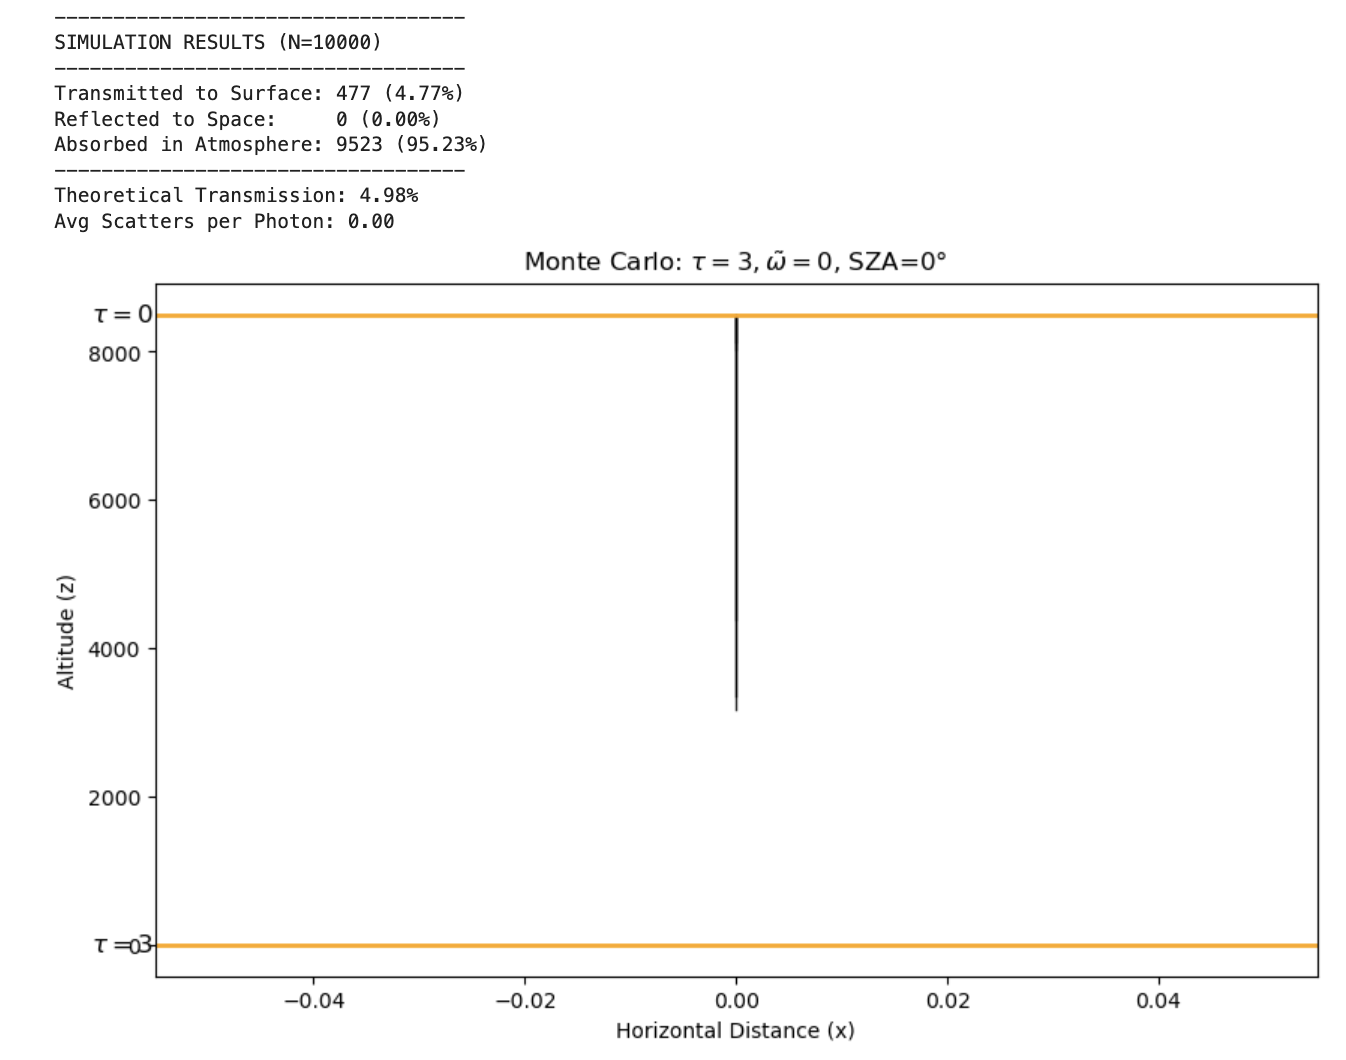
* **$\tilde{\omega} = 1$:** Only scattering occurs.
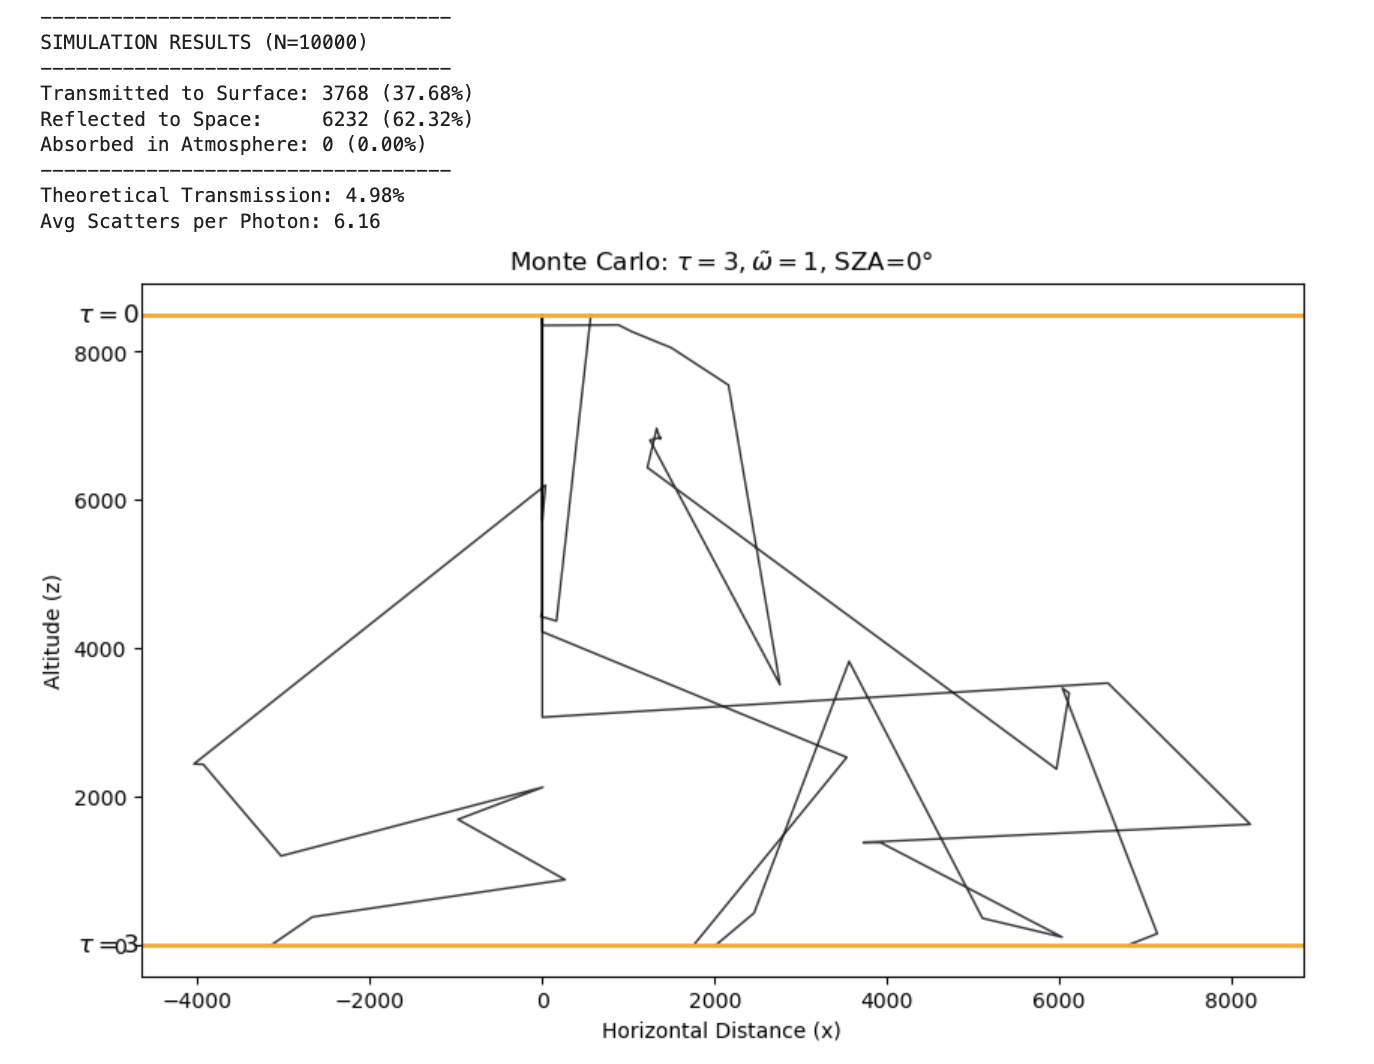
* **$\tilde{\omega} = 0.5$:** Extinction is split equally between scattering and absorption.
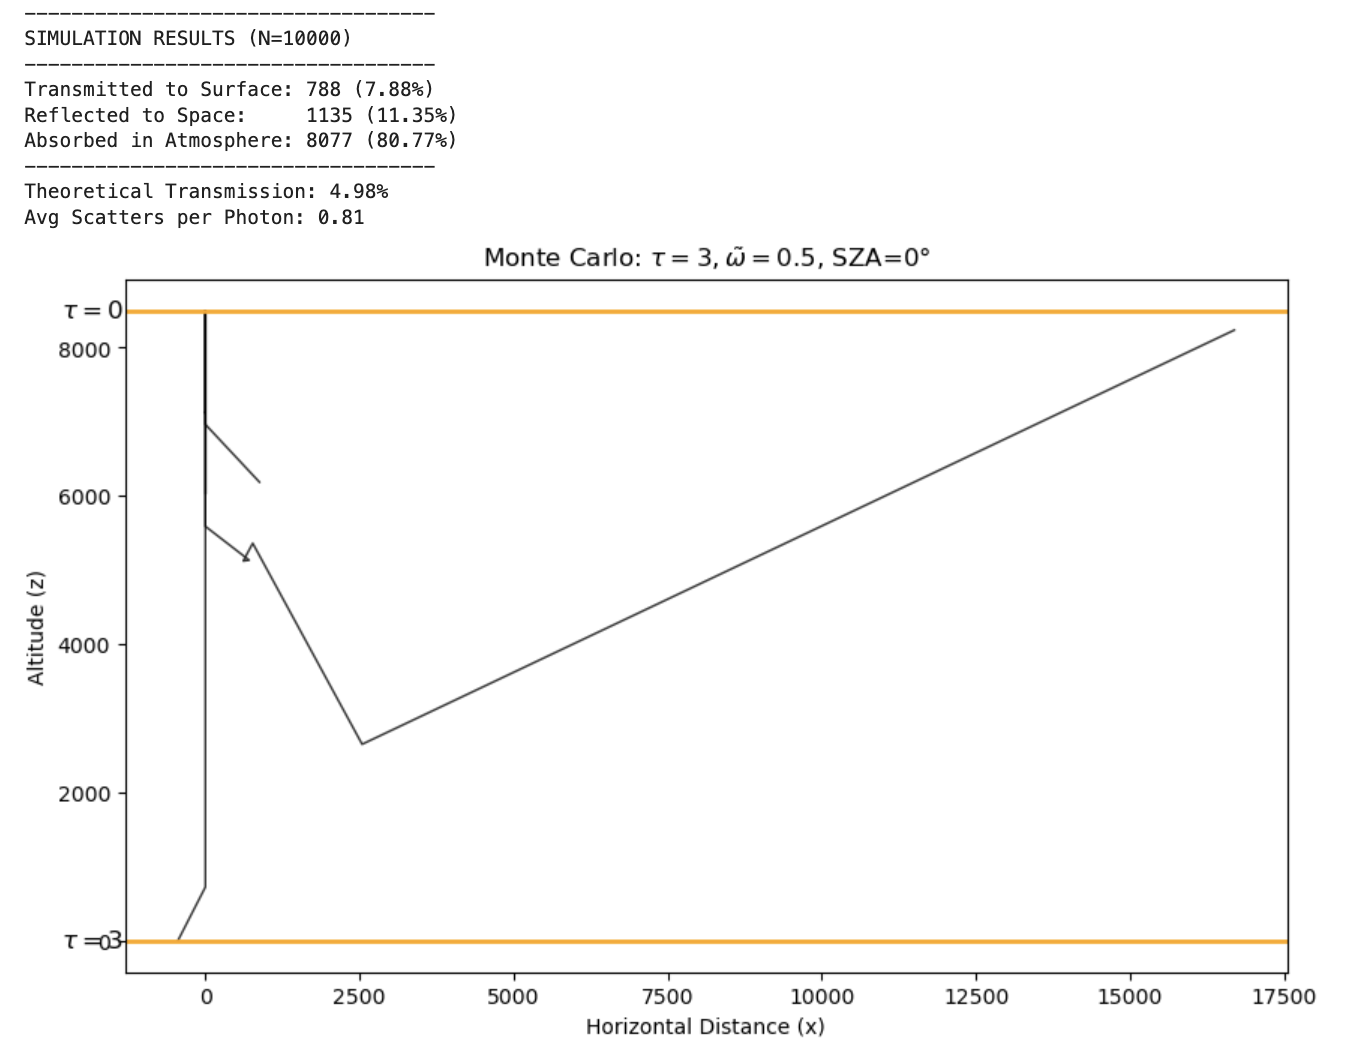
The measured $\tilde{\omega}$ from the simulation is calculated as:
$$\tilde{\omega} = \frac{n_{scat}}{n_{scat} + n_{abs}}$$

**Based on simulation output ($\tau=3, SZA=0^\circ, \tilde{\omega}=0.5$):**
* **Absorptions ($n_{abs}$):** $8077$
* **Scatters ($n_{scat}$):** $8100$
* **Total Events:** $16,177$

$$\frac{8100}{8100 + 8077} \approx \mathbf{0.5007}$$

---

#### **2. Actual vs. Theoretical Extinction**

* **Actual Total Transmission:** $7.88\%$
* **Actual Total Extinction:** $100 - 7.88 = \mathbf{92.12\%}$

**Theoretical Calculation:**
Using $T = e^{-\tau / \mu_0}$ where $\tau = 3$ and $\mu_0 = \cos(0^\circ) = 1$:
$$T_{theory} = e^{-3} \approx 0.0498 \text{ (4.98%)}$$
$$\text{Theoretical Extinction} = 100 - 4.98 = \mathbf{95.02\%}$$

---

#### **3. Diffuse Transmittance Contribution**
The "Actual" transmission in the model ($7.88\%$) is higher than the "Theoretical" transmission ($4.98\%$) because the model includes **diffuse transmittance** photons that scattered but eventually reached the surface.

$$\text{Diffuse Transmittance} = \text{Actual Transmission} - \text{Theoretical (Direct) Transmission}$$
$$7.88\% - 4.98\% = \mathbf{2.9\%}$$

**Conclusion:** In this simulation, $4.98\%$ of the light reached the surface directly, while $2.9\%$ reached the surface as diffuse (scattered) light.

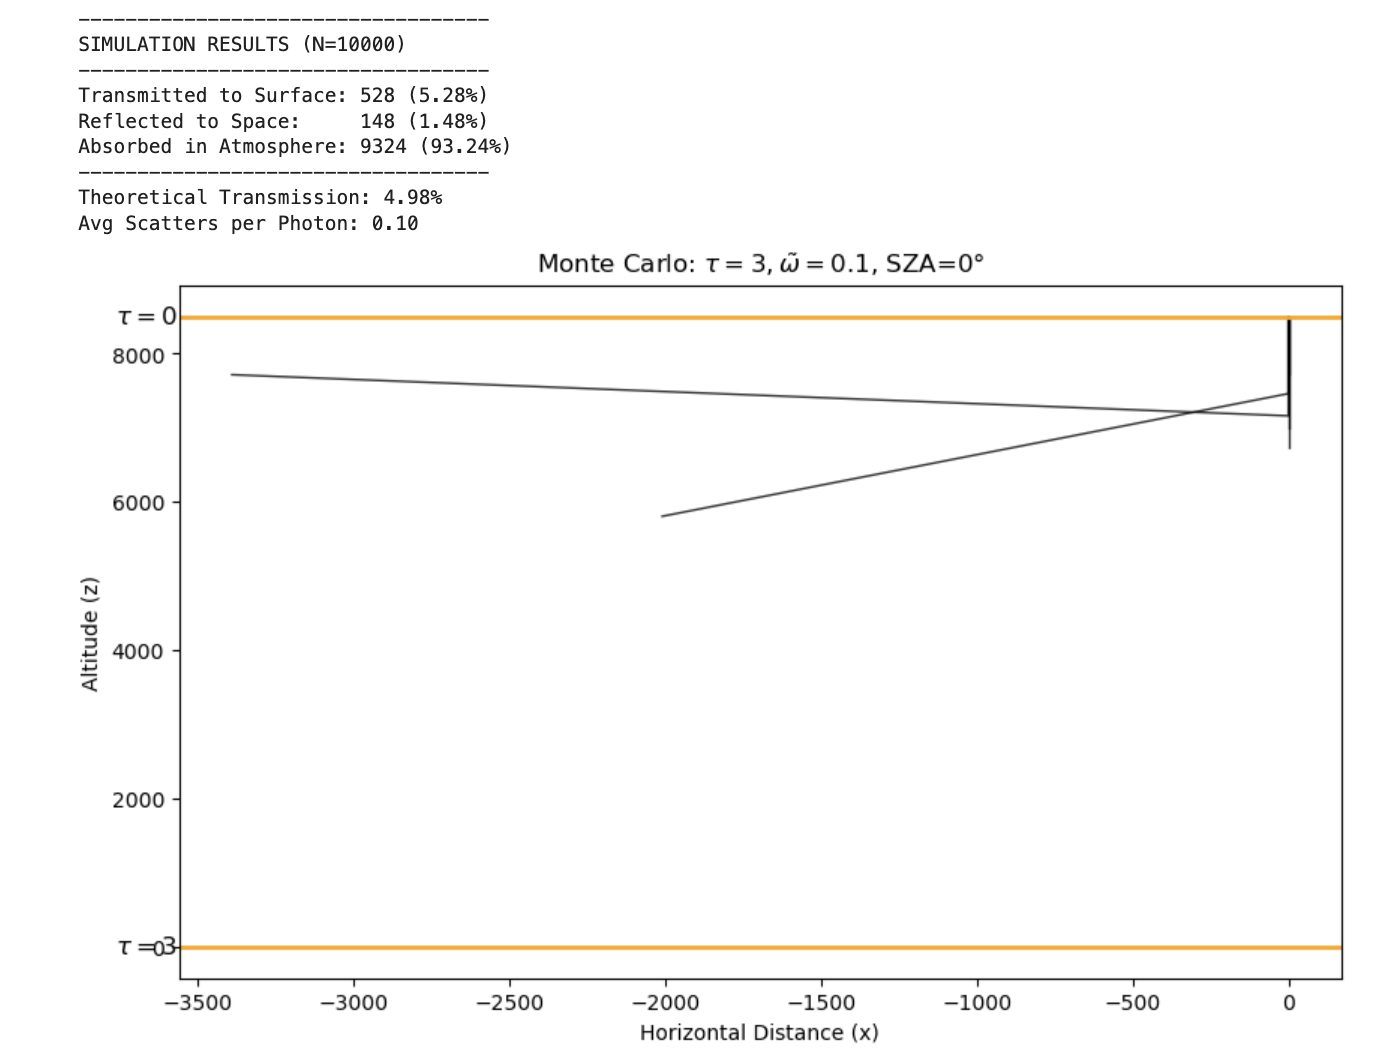
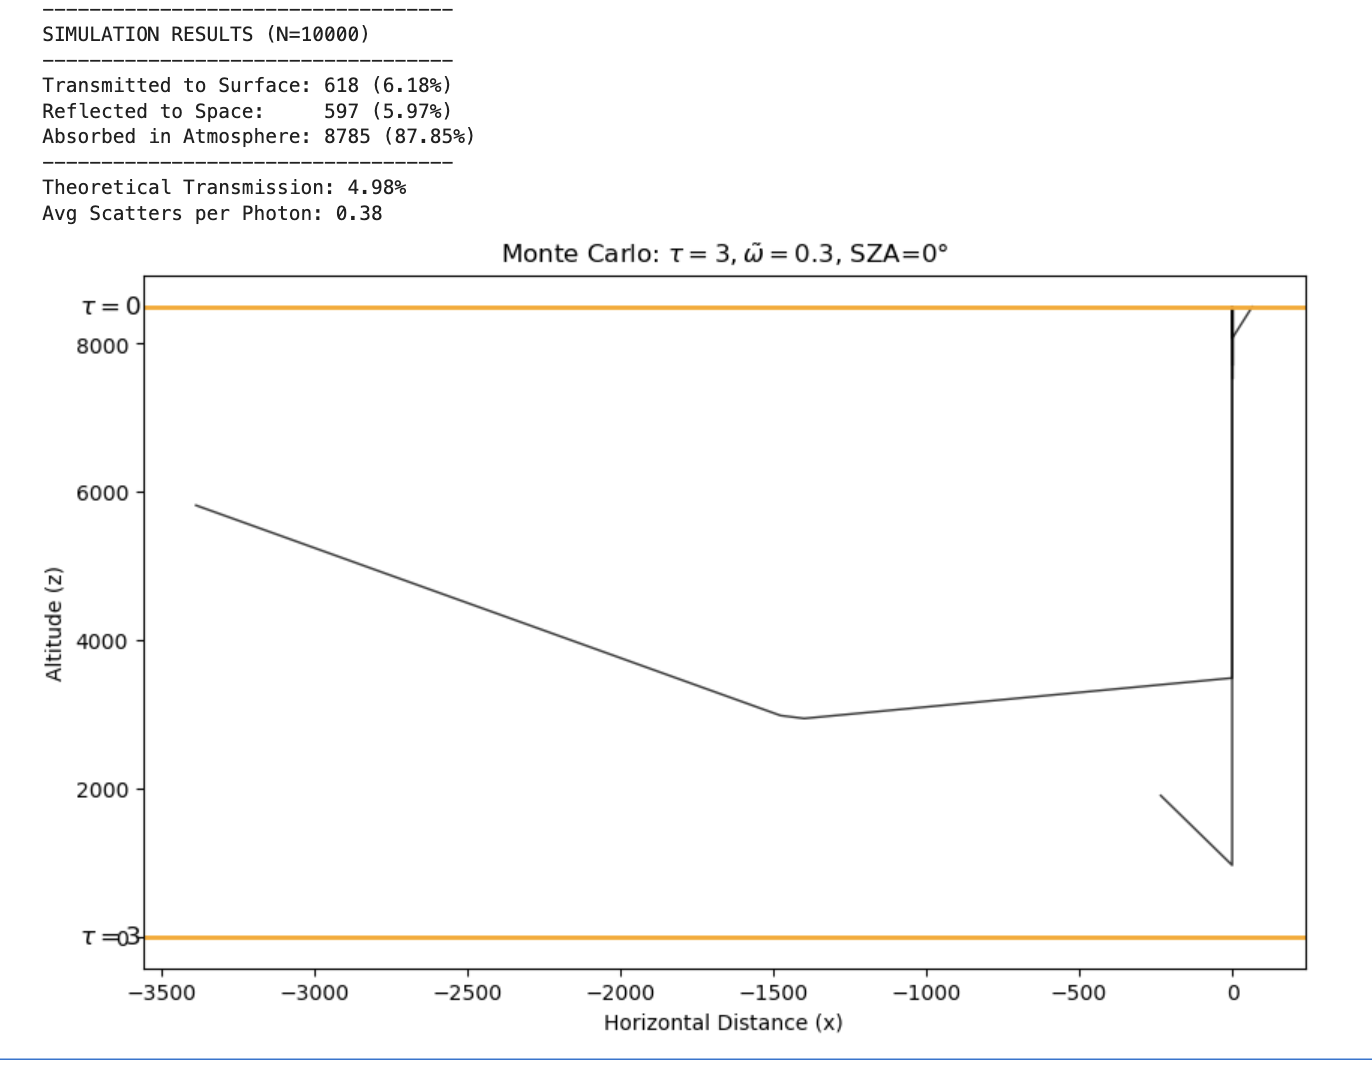
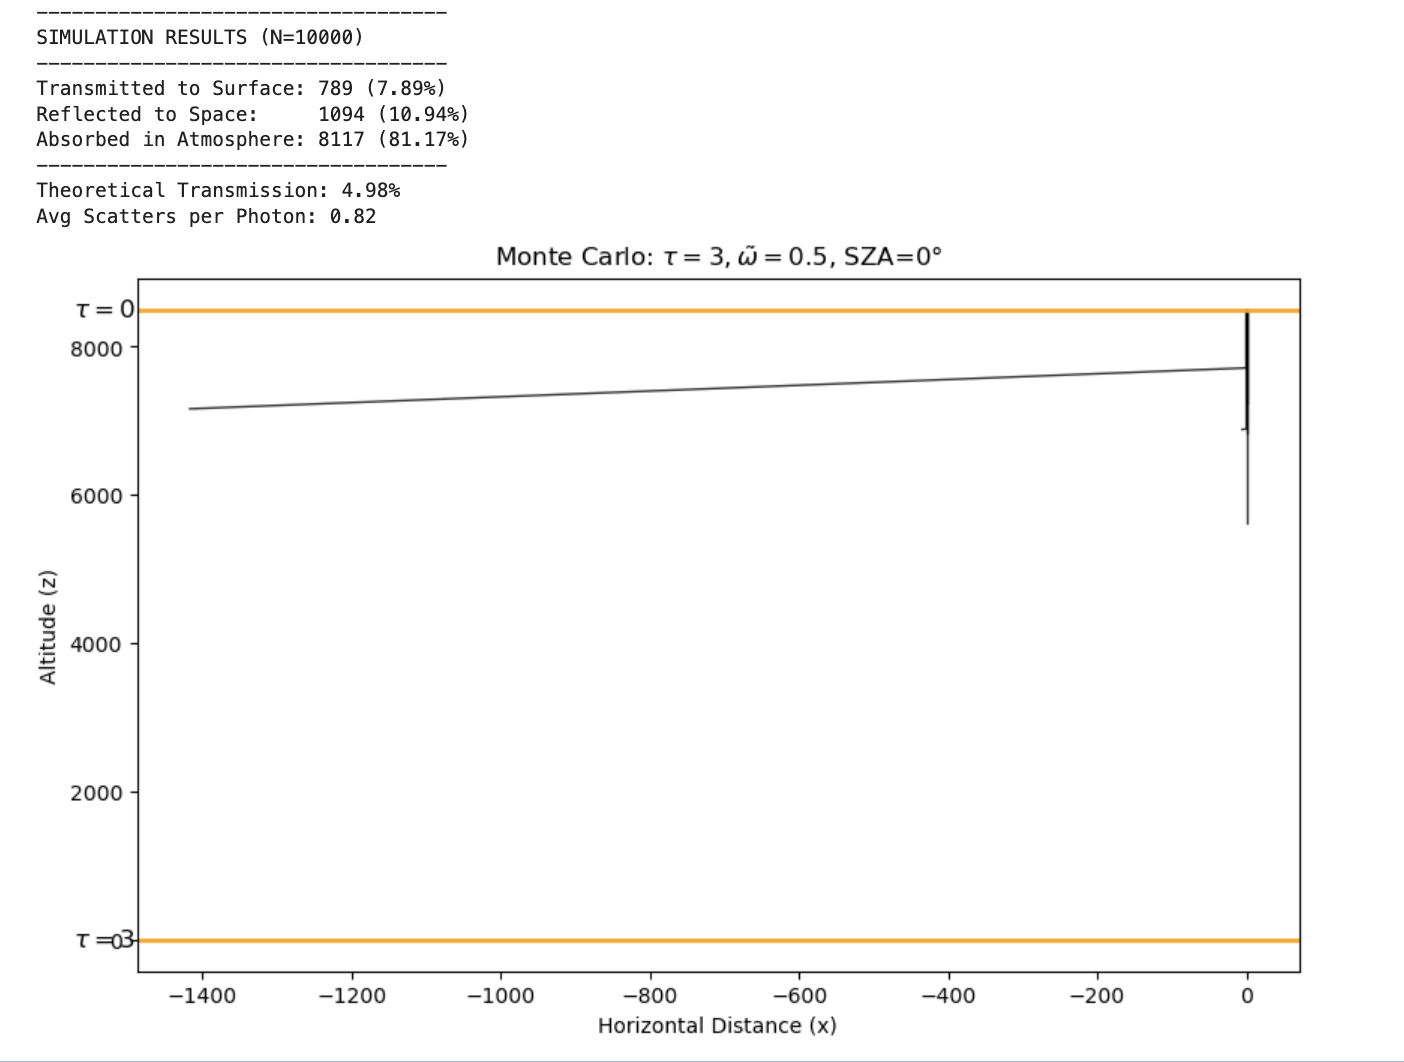
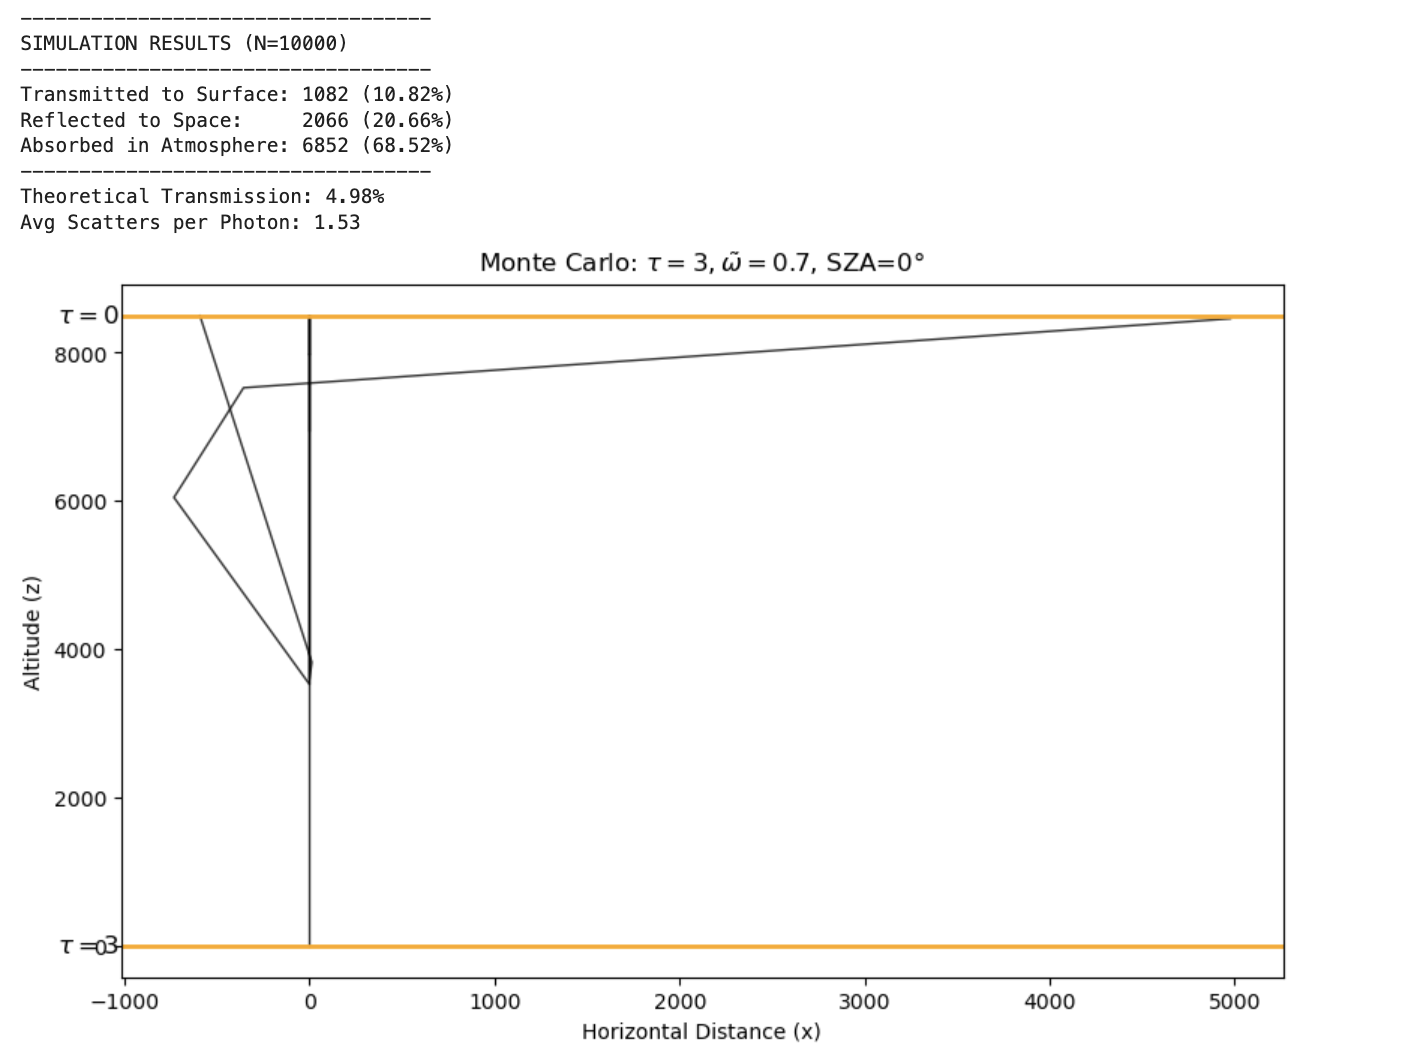
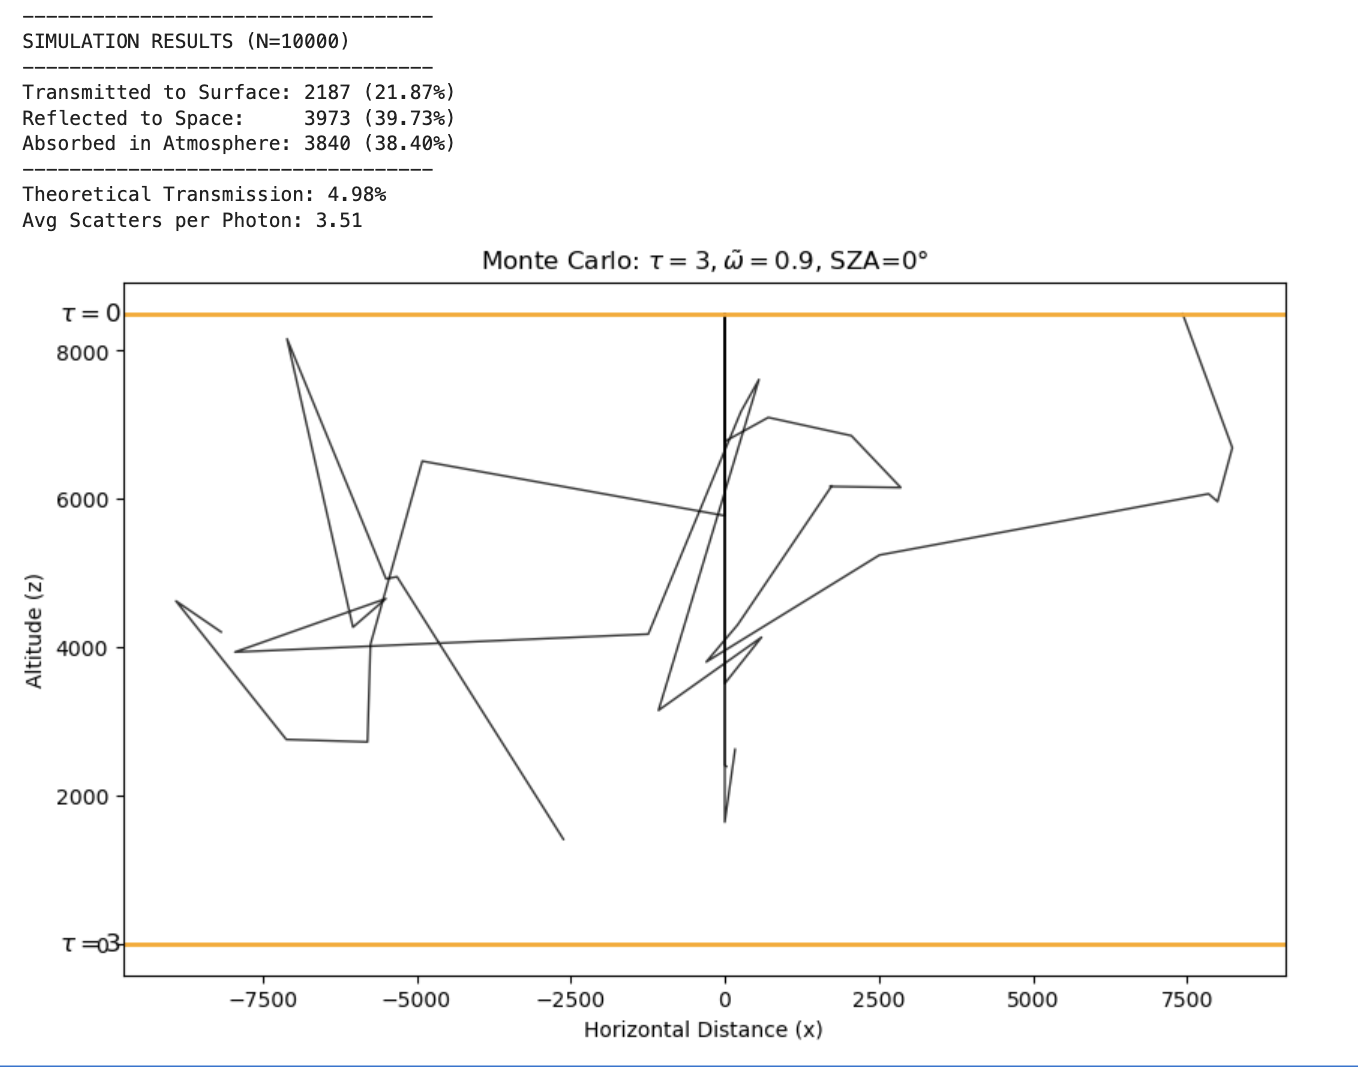

## Question A: For ˜ω increasing from 0 → 1, how does the the surface direct and diffuse transmittance, and the albedo, change?

As the single scattering albedo is increased from 0 to 1, the % transmittance to the surface increases, and if we compare this value to the theoretical transmittance, we can find that the diffuse transmittance also increases with increasing albedo. The overall reflectance, as a percentage of the total incident photons, also increases with increasing single-scatter albedo. 

Based on this table and the graph plotted below, we can see the trend: 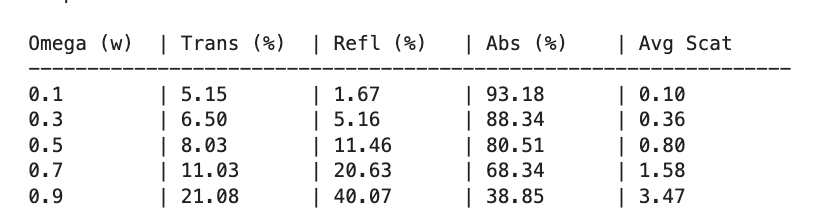

The diffuse transmittance with increasing single scatter albedo is: 0.17%, 1.52%, 3.05%, 6.05%, 16.1%, respectively 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def scatter_3d(k_old, cos_theta, phi):
    
    # 1. Define local z-axis as the current direction
    zp = k_old / np.linalg.norm(k_old)
    
    # 2. Define local x-axis (perpendicular to zp)
    if abs(zp[0]) < 1e-9 and abs(zp[1]) < 1e-9:
        xp = np.array([1.0, 0.0, 0.0])
    else:
        norm = 1.0 / np.sqrt(zp[0]**2 + zp[1]**2)
        xp = np.array([-zp[1] * norm, zp[0] * norm, 0.0])
    
    # 3. Define local y-axis
    yp = np.cross(zp, xp)
    
    # 4. Direction in local coordinates
    sin_theta = np.sqrt(max(0, 1 - cos_theta**2))
    kp = np.array([
        sin_theta * np.cos(phi),
        sin_theta * np.sin(phi),
        cos_theta
    ])
    
    # 5. Transform back to global coordinates (Matrix A @ kp)
    A = np.stack([xp, yp, zp], axis=1)
    k_new = A @ kp
    return k_new / np.linalg.norm(k_new)

def run_simulation(omega_tilde, n_incident=10000, tau_star=3, sza_deg=0):
   
    n_transmitted = 0
    n_reflected = 0
    n_absorbed = 0
    n_scatter_total = 0
    
    # Setup initial conditions
    sza_rad = np.radians(sza_deg)
    k_init = np.array([np.sin(sza_rad), 0, -np.cos(sza_rad)])
    z_atm = 8500.0
    dz_dtau = z_atm / tau_star
    
    for i in range(n_incident):
        pos = np.array([0.0, 0.0, z_atm])
        k = k_init.copy()
        active = True
        
        while active:
            # Sample distance to next interaction
            delta_tau = -np.log(1 - np.random.rand())
            step = k * (delta_tau * dz_dtau)
            new_pos = pos + step
            
            # Boundary Checks
            if new_pos[2] <= 0: # Hit Surface
                n_transmitted += 1
                active = False
            elif new_pos[2] >= z_atm: # Exit to Space
                n_reflected += 1
                active = False
            else:
                # Interaction Check (Extinction Event)
                pos = new_pos
                if np.random.rand() < omega_tilde:
                    # Scattering Event
                    n_scatter_total += 1
                    cos_theta = 2 * np.random.rand() - 1
                    phi_scat = 2 * np.pi * np.random.rand()
                    k = scatter_3d(k, cos_theta, phi_scat)
                else:
                    # Absorption Event
                    n_absorbed += 1
                    active = False
                    
    return {
        "omega": omega_tilde,
        "trans": (n_transmitted / n_incident) * 100,
        "refl": (n_reflected / n_incident) * 100,
        "abs": (n_absorbed / n_incident) * 100,
        "avg_scat": n_scatter_total / n_incident
    }

# --- Main execution and plotting ---
omegas = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

print
for o in omegas:
    res = run_simulation(o)
    results.append(res)
    print(f"Completed w = {o}")

# --- Print Table ---
print(f"\n{'Omega (w)':<10} | {'Trans (%)':<10} | {'Refl (%)':<10} | {'Abs (%)':<10} | {'Avg Scat'}")
print("-" * 65)
for r in results:
    print(f"{r['omega']:<10.1f} | {r['trans']:<10.2f} | {r['refl']:<10.2f} | {r['abs']:<10.2f} | {r['avg_scat']:.2f}")

# --- Generate Plot ---
plt.figure(figsize=(10, 6))
plt.plot(omegas, [r['trans'] for r in results], 'bo-', label='Transmittance')
plt.plot(omegas, [r['refl'] for r in results], 'go-', label='Albedo (Reflected)')
plt.plot(omegas, [r['abs'] for r in results], 'ro-', label='Atm. Absorption')

plt.axhline(y=4.98, color='k', linestyle='--', label='Theoretical Direct Beam (4.98%)')
plt.xlabel("Single Scattering Albedo (w)")
plt.ylabel("Percentage (%)")
plt.title("Radiative Components vs. Single Scattering Albedo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("radiative components vs single scattering albedo")
save_fig()
plt.show()

## Question B: for τ << 1, what is the relationship between diffuse radiation at the surface and ˜ω, τ , and μ0, and how does this compare to an approximate analytical solution to the RTE?
 ### **Single Scattering Approximation (Analytical Solution)**

For an optically thin atmosphere ($\tau \ll 1$), the fraction of incident radiation that reaches the surface as **diffuse radiation** ($F_{diff}$) can be approximated as:

$$F_{diff} \approx \frac{1}{2} \tilde{\omega} \left( \frac{\tau}{\mu_0} \right)$$

**Where:**
* **$\frac{\tau}{\mu_0}$:** This is the effective optical path length. As the Solar Zenith Angle (SZA) increases, $\mu_0$ ($\cos(\text{SZA})$) decreases, making the slant path longer and increasing the probability of scattering.
* **$\tilde{\omega}$:** Represents the probability that of a scattering event rather than absorption.
* **The factor of $1/2$:** Represents the assumption of **Isotropic Scattering**, where 50% of scattered photons are redirected into the downward hemisphere toward the surface.

The relationship between the montecarlo and analytical approx diffuse transmittance in an optically thin atmosphere is shown below

In [ ]:
import numpy as np


def get_diffuse_comparison(tau_val, omega_val, n_incident=50000):
    n_transmitted = 0
    mu0 = 1.0 # Zenith angle = 0
    z_atm = 8500
    dz_dtau = z_atm / tau_val
    k_init = np.array([0, 0, -1.0])

    for _ in range(n_incident):
        pos = np.array([0.0, 0.0, z_atm])
        k = k_init.copy()
        active = True
        while active:
            delta_tau = -np.log(1 - np.random.rand())
            step = k * (delta_tau * dz_dtau)
            new_pos = pos + step
            
            if new_pos[2] <= 0:
                n_transmitted += 1
                active = False
            elif new_pos[2] >= z_atm:
                active = False
            else:
                pos = new_pos
                if np.random.rand() < omega_val:
                    # Isotropic scatter
                    cos_theta = 2 * np.random.rand() - 1
                    phi = 2 * np.pi * np.random.rand()
                    sin_theta = np.sqrt(1 - cos_theta**2)
                    k = np.array([sin_theta*np.cos(phi), sin_theta*np.sin(phi), cos_theta])
                else:
                    active = False

    # 1. Calculate Actual Total Transmittance
    total_trans = n_transmitted / n_incident
    
    # 2. Calculate Theoretical Direct Transmittance
    direct_trans = np.exp(-tau_val / mu0)
    
    # 3. Isolate Diffuse (Actual - Direct)
    actual_diffuse = total_trans - direct_trans
    
    # 4. Analytical Approximation (for tau << 1)
    analytical_diffuse = 0.5 * omega_val * (tau_val / mu0)
    
    return actual_diffuse, analytical_diffuse

# --- Run Test for tau << 1 ---
tau_test = 0.1
omega_test = 0.5

actual, theory = get_diffuse_comparison(tau_test, omega_test)

print(f"Results for tau = {tau_test}, omega = {omega_test}:")
print("-" * 40)
print(f"Monte Carlo Diffuse:  {actual:.4f} ({actual*100:.2f}%)")
print(f"Analytical Diffuse:   {theory:.4f} ({theory*100:.2f}%)")
print(f"Percent Difference:   {abs(actual-theory)/theory*100:.2f}%")

## Why is the sky blue and sunsets red?

The increased pathlength through the atmosphere dictated by the SZA directly changes how many extinction events a photon can potentially encounter before reaching the surface. The effective optical depth is $\frac{\tau}{\mu_0}$ so when the sun is directly overhead in an atmosphere with and AOD of 1 the AOD remains 1 whereas when the SZA is 75˚ the effective optical depth is 3.86370. 

Why is a sunset red? The extinction of a photon also depends on the wavelength of the incident light. It is proportional to $\frac{1}{\lambda^4}$, so when the wavelength is higher (red ~ 620 to 750 nm), the extinction probability is lower than that of blue light (~ 380 to 500 nm). When the effective pathlength for light to travel is longer, as at sunset, increased extinction events affect blue light more than red, allowing more red light to reach the surface. This is shown below by the change in transmittance and scattering events per photon for an SZA of 0 and 75

Why is the sky blue? The sky is blue due to Rayleigh Scattering, but in terms of extinction events, it is because when the sun is overhead, the effective path length is lower. This limits the number of extinction events an incident photon can encounter, so more light of all wavelengths reaches the surface. 

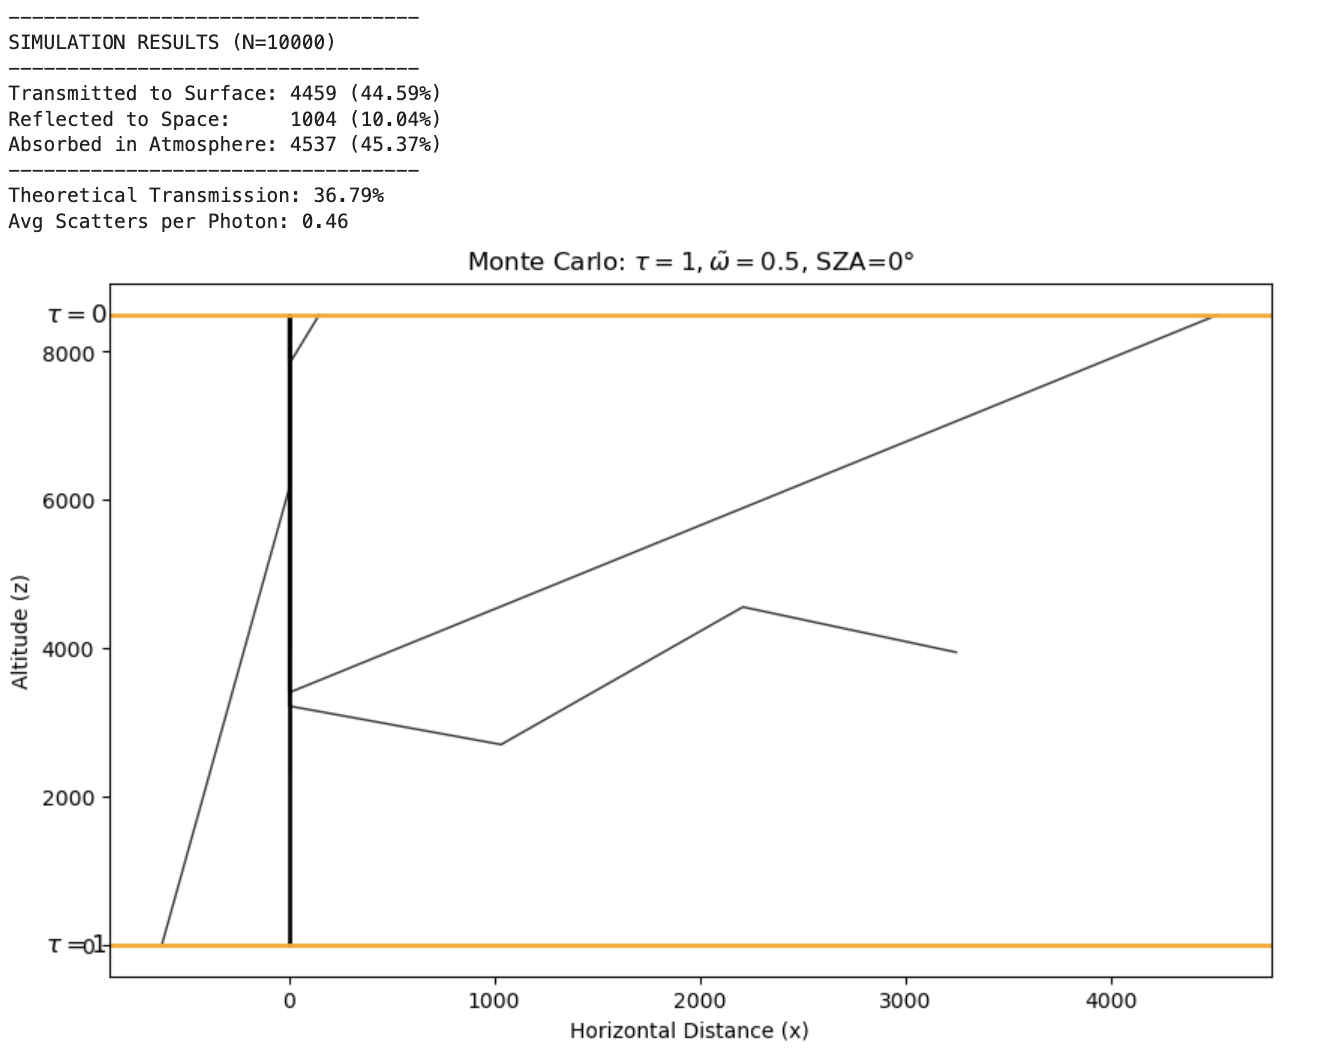
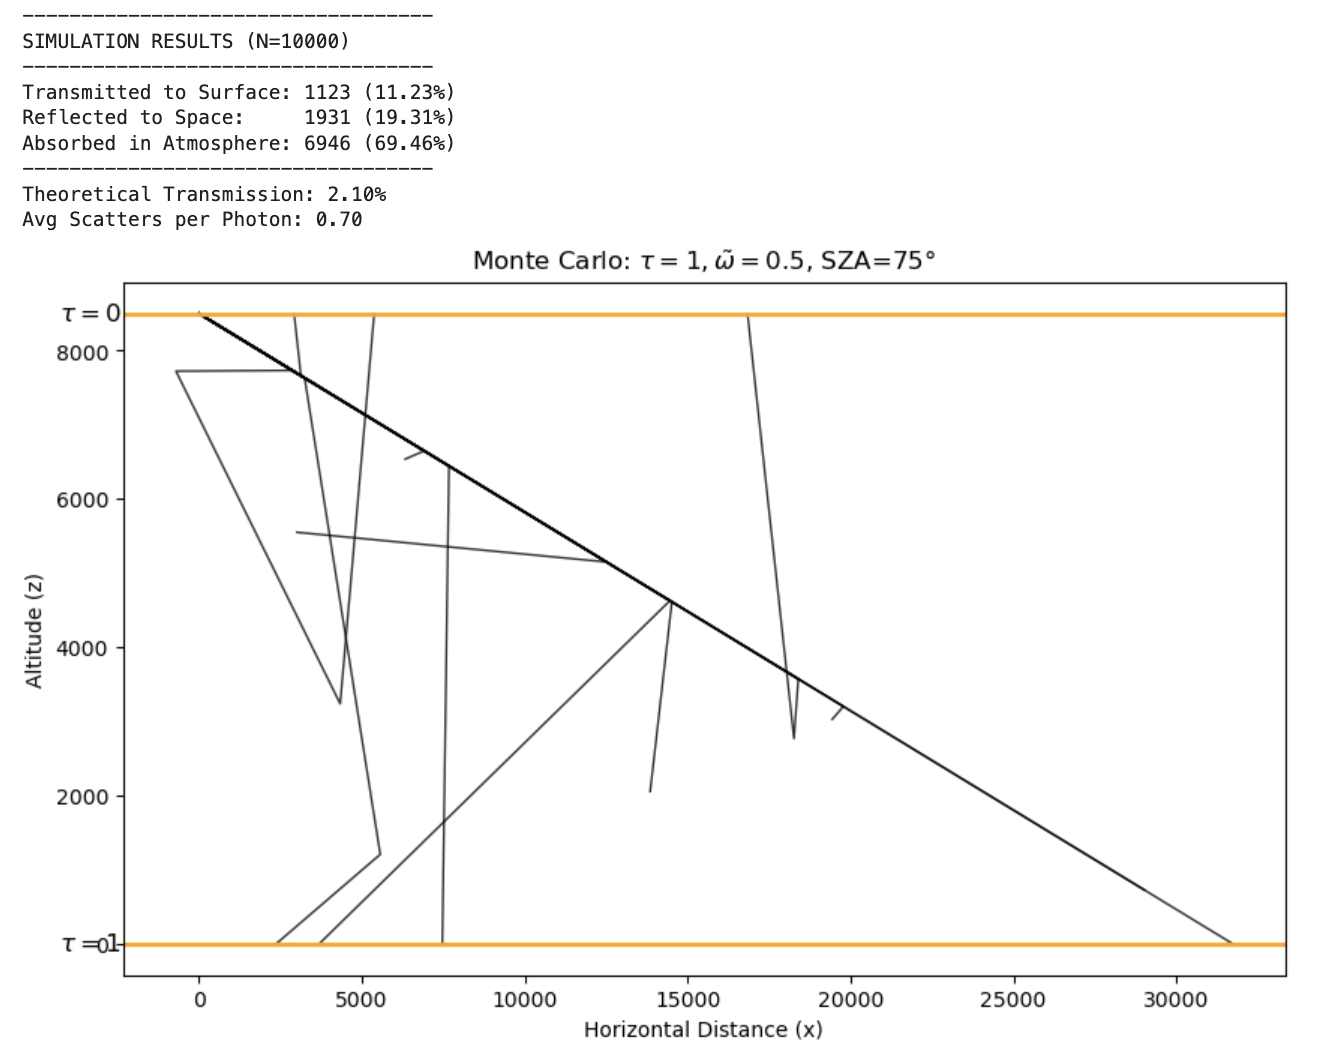

-----------------------------------
SIMULATION RESULTS (N=10000)
-----------------------------------
Transmitted to Surface: 1122 (11.22%)
Reflected to Space:     1918 (19.18%)
Absorbed in Atmosphere: 6960 (69.60%)
-----------------------------------
Theoretical Transmission: 2.10%
Avg Scatters per Photon: 0.69


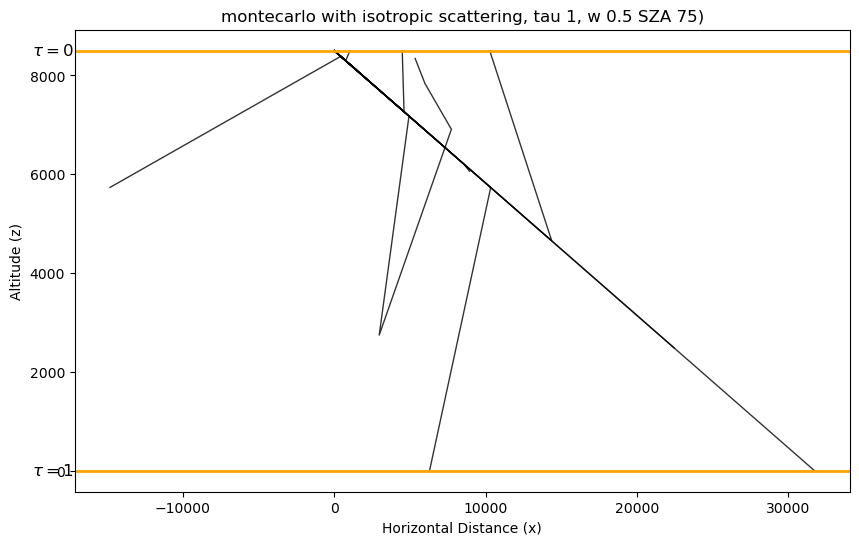

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt

if not os.path.exists("figures"):
    os.makedirs("figures")
    
# --- Parameters ---
N_INCIDENT = 10000 
N_PLOT = 20           # Number of paths to display visually
TAU_STAR = 1         # Optical Depth
OMEGA_TILDE = 0.5      # 0 for pure absorption, 1 for pure scattering
SZA_DEG = 75         # Solar Zenith Angle
Z_ATM = 8500         # Physical Height of Atmosphere

def scatter_3d(k_old, cos_theta, phi_scat):
    zp = k_old / np.linalg.norm(k_old)
    kx, ky, kz = zp
    
    if abs(kx) < 1e-9 and abs(ky) < 1e-9:
        xp = np.array([1.0, 0.0, 0.0])
    else:
        norm = 1.0 / np.sqrt(kx**2 + ky**2)
        xp = np.array([-ky * norm, kx * norm, 0.0])
    
    yp = np.cross(zp, xp)
    sin_theta = np.sqrt(max(0, 1 - cos_theta**2))
    kp = np.array([sin_theta * np.cos(phi_scat), 
                   sin_theta * np.sin(phi_scat), 
                   cos_theta])
    
    A = np.stack([xp, yp, zp], axis=1)
    k_new = A @ kp
    return k_new / np.linalg.norm(k_new)

def run_simulation():
    plt.figure(figsize=(10, 6))
    
    
    dz_dtau = Z_ATM / TAU_STAR 

    # Initial direction vector
    sza_rad = np.radians(SZA_DEG)
    k_init = np.array([np.sin(sza_rad), 0, -np.cos(sza_rad)])

    # Initialize counters
    n_scatter_total = 0
    n_absorbed = 0
    n_reflected = 0
    n_transmitted = 0

    for i in range(N_INCIDENT):
        pos = np.array([0.0, 0.0, Z_ATM]) 
        k = k_init.copy()
        path_x, path_z = [pos[0]], [pos[2]]
        active = True
        
        while active:
            # Sample optical path
            delta_tau = -np.log(1 - np.random.rand())
            
           
            step = k * (delta_tau * dz_dtau)
            new_pos = pos + step
            
            # Boundary Checks
            if new_pos[2] <= 0: # Hit Surface
                # Interpolate to find exact exit point at z=0
                fraction = pos[2] / abs(step[2]) if step[2] != 0 else 0
                final_pos = pos + step * fraction
                path_x.append(final_pos[0]); path_z.append(0)
                n_transmitted += 1
                active = False
            elif new_pos[2] >= Z_ATM: # Escaped TOA
                fraction = (Z_ATM - pos[2]) / step[2] if step[2] != 0 else 0
                final_pos = pos + step * fraction
                path_x.append(final_pos[0]); path_z.append(Z_ATM)
                n_reflected += 1
                active = False
            else:
                # Still inside atmosphere
                pos = new_pos
                path_x.append(pos[0]); path_z.append(pos[2])
                
                # Interaction Logic
                if np.random.rand() < OMEGA_TILDE:
                    n_scatter_total += 1
                    cos_theta = 2 * np.random.rand() - 1
                    phi_scat = 2 * np.pi * np.random.rand()
                    k = scatter_3d(k, cos_theta, phi_scat)
                else:
                    n_absorbed += 1
                    active = False

        # Plot first few paths
        if i < N_PLOT:
            plt.plot(path_x, path_z, color='black', linewidth=1, alpha=0.8)

    # --- Formatting Plot ---
    plt.axhline(y=Z_ATM, color='orange', linewidth=2)
    plt.axhline(y=0, color='orange', linewidth=2)
    plt.text(plt.xlim()[0], Z_ATM, r'$\tau = 0$ ', fontsize=12, va='center', ha='right')
    plt.text(plt.xlim()[0], 0, fr'$\tau = {TAU_STAR}$ ', fontsize=12, va='center', ha='right')
    plt.title(fr"Monte Carlo: $\tau={TAU_STAR}, \tilde{{\omega}}={OMEGA_TILDE}$, SZA={SZA_DEG}°")
    plt.ylabel("Altitude (z)")
    plt.xlabel("Horizontal Distance (x)")
    plt.title("montecarlo with isotropic scattering, tau 1, w 0.5 SZA 75)")
   
    # --- Print Final Statistics ---
    print("-" * 35)
    print(f"SIMULATION RESULTS (N={N_INCIDENT})")
    print("-" * 35)
    print(f"Transmitted to Surface: {n_transmitted} ({n_transmitted/N_INCIDENT*100:.2f}%)")
    print(f"Reflected to Space:     {n_reflected} ({n_reflected/N_INCIDENT*100:.2f}%)")
    print(f"Absorbed in Atmosphere: {n_absorbed} ({n_absorbed/N_INCIDENT*100:.2f}%)")
    print("-" * 35)
    print(f"Theoretical Transmission: {np.exp(-TAU_STAR/np.cos(sza_rad))*100:.2f}%")
    print(f"Avg Scatters per Photon: {n_scatter_total/N_INCIDENT:.2f}")

# Run it
run_simulation()

# Student investigation 

## Primary Question

How will the average scattering events per photon change with increasing single scattering albedo in an atmosphere with AOD 3 at midday?

## Hypothesis
As the single scatter albedo increases, the average scattering per particle will increase at a nonlinear rate. Once the single scattering albedo is sufficiently large ~0.8, the photon will have a rapid increase in average scatters since the likelihood of absorption is low enough that the particle can scatter many times before experiencing an absorption extinction event.

## Experimental Method

I kept the AOD at a constant value of 3 and the SZA at 0 while increasing the single-scattering albedo to determine the average number of scatterers per incident photon. The results are shown below: 
 
 w=0.10: Avg Scatters = 0.11
 w=0.30: Avg Scatters = 0.38
 w=0.50: Avg Scatters = 0.82
 w=0.70: Avg Scatters = 1.59
 w=0.80: Avg Scatters = 2.30
 w=0.90: Avg Scatters = 3.49
 w=0.95: Avg Scatters = 4.53
 w=0.99  Avg Scatters = 5.82

 This aligns with my hypothesis that the average scattering per particle will increase at a nonlinear rate. Once the single scattering albedo is sufficiently large, around 0.8, the photon will have a rapid increase in average scatters


 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_investigation(omega_values, tau=3.0, n_incident=10000):
    avg_scatters = []
    
    for w in omega_values:
        n_scat_total = 0
        for _ in range(n_incident):
            # Photon initialization
            pos_z = 8500.0
            k_z = -1.0 # Zenith SZA = 0
            active = True
            
            while active:
                # 1. Sample step distance
                dt = -np.log(1 - np.random.rand())
                step_z = k_z * (dt * (8500.0 / tau))
                pos_z += step_z
                
                # 2. Boundary checks
                if pos_z <= 0 or pos_z >= 8500.0:
                    active = False
                else:
                    # 3. Interaction: Scatter or Absorb?
                    if np.random.rand() < w:
                        n_scat_total += 1
                        # Isotropic scattering: new random z-direction
                        k_z = 2 * np.random.rand() - 1 
                    else:
                        active = False # Absorbed
                        
        avg_scatters.append(n_scat_total / n_incident)
        print(f"Finished w={w:.2f}: Avg Scatters = {avg_scatters[-1]:.2f}")
    
    return avg_scatters

# --- Parameters ---
omega_sweep = np.array([0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99])
scatters = run_investigation(omega_sweep)

# --- Plotting the Hypothesis Test ---
plt.figure(figsize=(10, 6))
plt.plot(omega_sweep, scatters, 'ro-', linewidth=2, label='Model Results')

# Reference line to show non-linearity
linear_ref = [scatters[0] + (scatters[-1]-scatters[0])*(w-omega_sweep[0])/(omega_sweep[-1]-omega_sweep[0]) for w in omega_sweep]
plt.plot(omega_sweep, linear_ref, 'k--', alpha=0.5, label='Linear Trend (Reference)')

plt.title("Hypothesis Test: Average Scatters vs. Single-Scattering Albedo")
plt.xlabel(r"Single-Scattering Albedo ($\tilde{\omega}$)")
plt.ylabel("Avg Scatters per Incident Photon")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.title("hypothesis test avg scat vs single scat albedo")
save_fig()

plt.show()

# AI Usage
## Tool used: Google Gemini
How it was used: wrote all initial Python code. The prompt was to incorporate my hand-derived functions (from Notability) into markdown code and incorporate into my montecarlo model from HW 1 to account for isotropic scattering.

What I checked: When I was doing the verification tests, I calculated my expected values/ observations beforehand and then checked to see how well the model aligned. I noticed discrepancies in the number of photons absorbed between my theoretical calculations and the model, so I manually adjusted my model.

What I changed: The model was not correctly accounting for the scale height initially, so the amount of photons absorbed and photons transmitted was higher and lower than my expectations, while the scattering remained consistent. I figured out that the model was not scaling correctly for height so the effective tau was so large that almost no radiation was being transmitted to the surface. I fixed this by incorporating a scale factor of dz_dtau = z_atm / tau_star to align the model with my theoretical calculations. 